In [23]:
import os

base_path = r"C:\Users\asmaa\OneDrive\Desktop\aclImdb_v1\aclImdb"

print(os.listdir(base_path))

['imdb.vocab', 'imdbEr.txt', 'README', 'test', 'train']


In [24]:
import os

data = []
labels = []

base_path = r"C:\Users\asmaa\OneDrive\Desktop\aclImdb_v1\aclImdb"
pos_path = os.path.join(base_path, "train", "pos")
neg_path = os.path.join(base_path, "train", "neg")

# positive
for file in os.listdir(pos_path):
    with open(os.path.join(pos_path, file), encoding="utf-8") as f:
        data.append(f.read())
        labels.append(1)

# negative
for file in os.listdir(neg_path):
    with open(os.path.join(neg_path, file), encoding="utf-8") as f:
        data.append(f.read())
        labels.append(0)

print("Total samples:", len(data))

Total samples: 25000


In [25]:
pip install pandas numpy scikit-learn nltk matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import pandas as pd

df = pd.DataFrame({
    "text": data,
    "label": labels
})

df.head()

,text,label
0,Bromwell High is a cartoon comedy. It ran at t...,1
1,Homelessness (or Houselessness as George Carli...,1
2,Brilliant over-acting by Lesley Ann Warren. Be...,1
3,This is easily the most underrated film inn th...,1
4,This is not the typical Mel Brooks film. It wa...,1


In [27]:
print(df.shape)
print(df["label"].value_counts())

(25000, 2)
label
1    12500
0    12500
Name: count, dtype: int64


In [28]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB
None


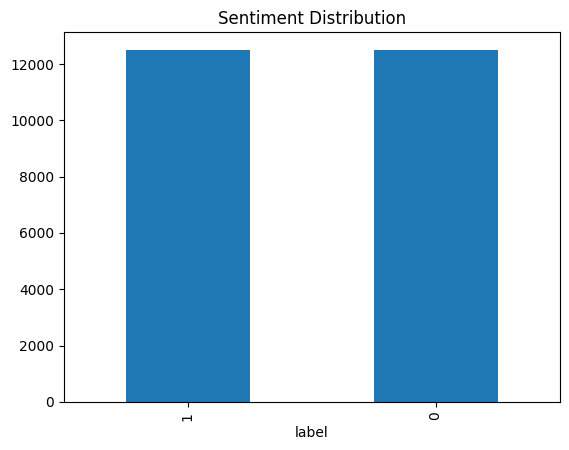

In [29]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.show()

In [30]:
import re

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'<.*?>', '', text)  # remove HTML tags
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation/numbers
    return text

df["clean_text"] = df["text"].apply(clean_text)

In [31]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

df["clean_text"] = df["clean_text"].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\asmaa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [32]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stem_text(text):
    return " ".join([stemmer.stem(word) for word in text.split()])

df["clean_text"] = df["clean_text"].apply(stem_text)

In [33]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [56]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


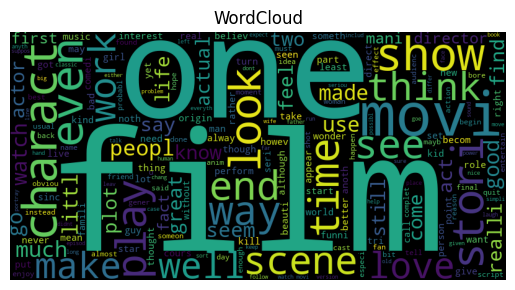

In [57]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["clean_text"])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.title("WordCloud")
plt.show()

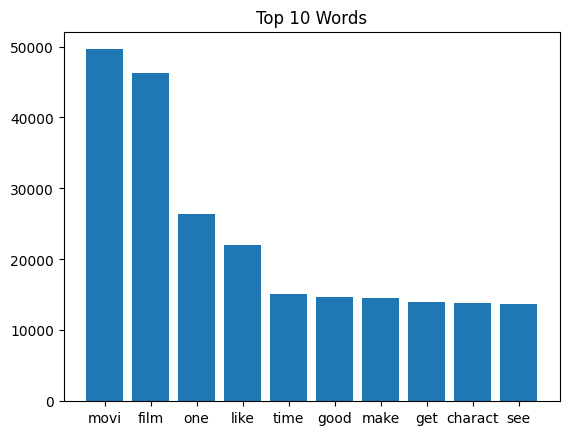

In [58]:
from collections import Counter

all_words = " ".join(df["clean_text"]).split()
common_words = Counter(all_words).most_common(10)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.title("Top 10 Words")
plt.show()

In [73]:
def preprocess_input(text):
    text = clean_text(text)
    text = remove_stopwords(text)
    text = stem_text(text)
    return text

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [35]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

In [36]:
y_pred = model.predict(X_test_vec)

In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8808

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88      2485
           1       0.88      0.89      0.88      2515

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000


Confusion Matrix:
 [[2171  314]
 [ 282 2233]]


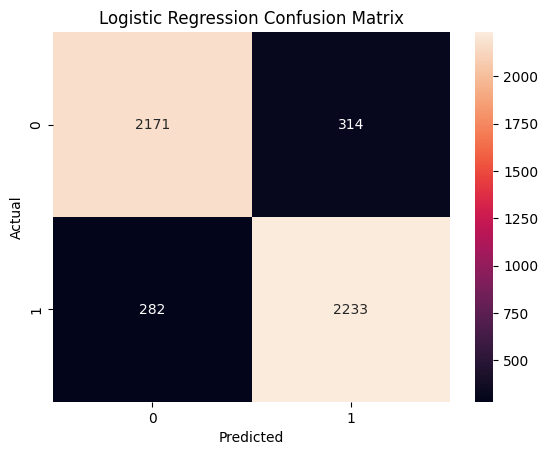

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [74]:
sample = ["This movie was amazing and I loved it"]

sample_clean = [preprocess_input(text) for text in sample]
sample_vec = vectorizer.transform(sample_clean)

prediction = model.predict(sample_vec)

print("Prediction:", "Positive" if prediction[0] == 1 else "Negative")

Prediction: Positive


In [40]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,   
    random_state=42,
    n_jobs=-1          
)

rf_model.fit(X_train_vec, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [41]:
y_pred_rf = rf_model.predict(X_test_vec)

In [42]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.8424

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84      2485
           1       0.85      0.83      0.84      2515

    accuracy                           0.84      5000
   macro avg       0.84      0.84      0.84      5000
weighted avg       0.84      0.84      0.84      5000


Confusion Matrix:
 [[2131  354]
 [ 434 2081]]


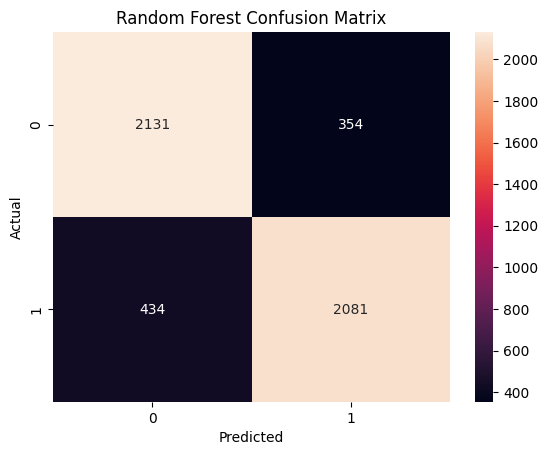

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [75]:
sample = ["This movie was very boring and bad"]

sample_clean = [preprocess_input(text) for text in sample]
sample_vec = vectorizer.transform(sample_clean)

prediction = rf_model.predict(sample_vec)

print("Prediction:", "Positive" if prediction[0] == 1 else "Negative")

Prediction: Negative


In [63]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

MultinomialNB()

In [64]:
y_pred_nb = nb_model.predict(X_test_vec)

In [65]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.852

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.84      0.85      2485
           1       0.85      0.86      0.85      2515

    accuracy                           0.85      5000
   macro avg       0.85      0.85      0.85      5000
weighted avg       0.85      0.85      0.85      5000


Confusion Matrix:
 [[2088  397]
 [ 343 2172]]


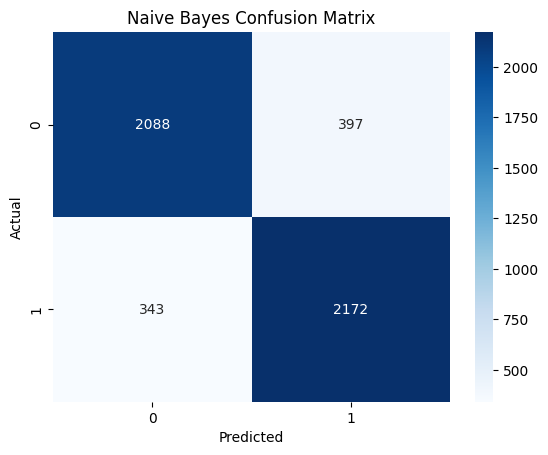

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [76]:
sample = ["This movie was boring and bad"]
sample_clean = [preprocess_input(text) for text in sample]
sample_vec = vectorizer.transform(sample_clean)

prediction = nb_model.predict(sample_vec)
print("Prediction:", "Positive" if prediction[0] == 1 else "Negative")

Prediction: Negative


In [67]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_vec, y_train)

LinearSVC()

In [68]:
y_pred_svm = svm_model.predict(X_test_vec)

In [69]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.8706

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87      2485
           1       0.87      0.87      0.87      2515

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000


Confusion Matrix:
 [[2156  329]
 [ 318 2197]]


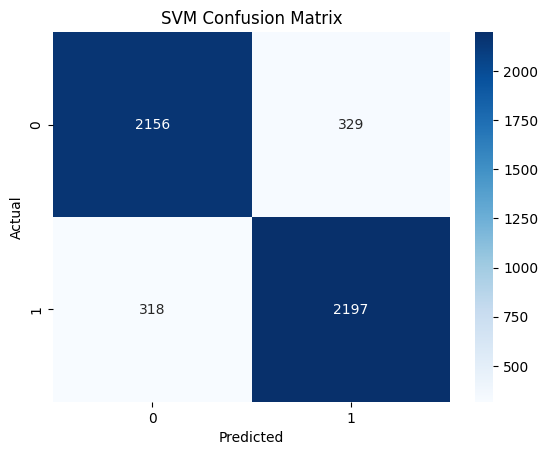

In [49]:
cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

In [77]:
sample = ["This movie was amazing and wonderful"]

sample_clean = [preprocess_input(text) for text in sample]
sample_vec = vectorizer.transform(sample_clean)

prediction = svm_model.predict(sample_vec)

print("Prediction:", "Positive" if prediction[0] == 1 else "Negative")

Prediction: Positive


In [78]:
from sklearn.neural_network import MLPClassifier

nn_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=10, random_state=42)
nn_model.fit(X_train_vec, y_train)

C:\Users\asmaa\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(max_iter=10, random_state=42)

In [79]:
y_pred_nn = nn_model.predict(X_test_vec)

In [80]:
print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nn))

Neural Network Accuracy: 0.8638

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.86      0.86      2485
           1       0.86      0.87      0.87      2515

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000


Confusion Matrix:
 [[2134  351]
 [ 330 2185]]


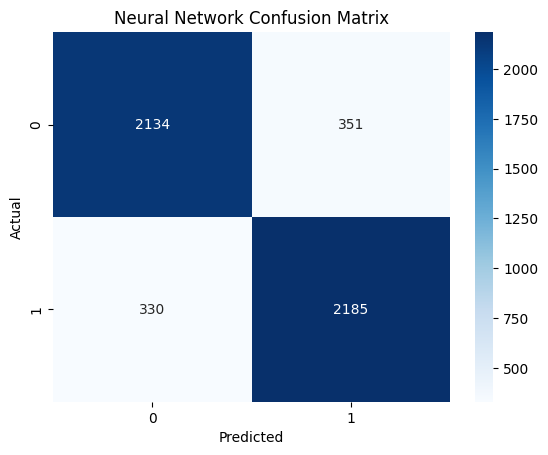

In [52]:
cm = confusion_matrix(y_test, y_pred_nn)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Neural Network Confusion Matrix")
plt.show()

In [81]:
sample = ["The movie was terrible and boring"]
sample_clean = [preprocess_input(text) for text in sample]
sample_vec = vectorizer.transform(sample_clean)

prediction = nn_model.predict(sample_vec)
print("Prediction:", "Positive" if prediction[0] == 1 else "Negative")

Prediction: Negative


In [83]:
import pandas as pd
from sklearn.metrics import accuracy_score

results = {
    "Model": ["Logistic Regression", "Random Forest", "Naive Bayes", "SVM", "Neural Network"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_nn)
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy
0  Logistic Regression    0.8808
1        Random Forest    0.8424
2          Naive Bayes    0.8520
3                  SVM    0.8706
4       Neural Network    0.8638


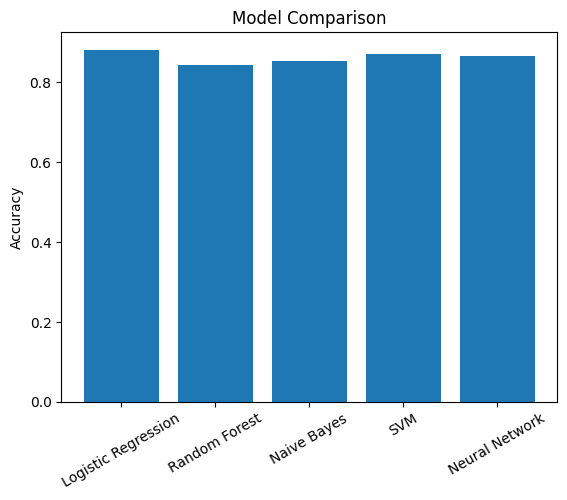

In [84]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=30)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()